<a href="https://colab.research.google.com/github/MiguelPastorB/pastorbeltra/blob/main/Tabular.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 1 Parte 2: Entornos complejos - Métodos tabulares
- **Alumno:** Pastor Beltrá, Miguel
- **Asignatura:** Extensiones de Machine Learning
- **Curso:** 2025/2026
- **Grupo:** pastorbeltra

**Índice**   
1. [Introducción](#introduccion)
2. [Desarrollo](#desarrollo)
3. [Algoritmos](#algoritmos)
4. [Evaluación](#evaluacion)
5. [Conclusiones](#conclusiones)
6. [Uso de la IA generativa](#ia-generativa)
7. [Bibliografía y referencias](#referencias)

# 1. Introducción <a name="introduccion"></a>

En esta segunda parte de la práctica, estudiamos los **Procesos de Decisión de Markov (MDP)** aplicados Aprendizaje por Refuerzo (RL). A diferencia de los problemas de bandidos de $k$-brazos, donde el entorno es estacionario y no hay cambio de estado , los entornos complejos requieren que un agente interactúe con un sistema que evoluciona en el tiempo.

El objetivo es que el agente aprenda una forma de actuar, la cual dicta qué acción tomar en cada estado para maximizar la recompensa acumulada a largo plazo. Para ello, evaluaremos algoritmos fundamentales que resuelven las **ecuaciones de Bellman** mediante la experiencia directa:

* **Métodos de Diferencias Temporales (TD):** SARSA y Q-Learning

* **Métodos de Monte Carlo:** específicamente la variante Every-Visit

# 2. Desarrollo <a name="desarrollo"></a>

El desarrollo experimental lo hemos estructurado para observar cómo estos algoritmos gestionan la incertidumbre y el riesgo en dos entornos de la librería **Gymnasium**.

## 2.1. Entorno Colab y VSCode

A continuación, incluimos algunas celdas auxiliares para adaptar el entorno de ejecución en Colab, permitiendo acceder correctamente al repositorio y a los módulos del proyecto.

In [1]:
#!rm -r pastorbeltra/
#!git clone https://github.com/MiguelPastorB/pastorbeltra.git
#!cd pastorbeltra/

Esta celda de código añade la carpeta src al path de Python, lo que permite importar correctamente los módulos del proyecto sin necesidad de instalar el paquete.

In [2]:
import sys
import os

# Añadimos la carpeta 'src' al path de búsqueda de Python
sys.path.append(os.path.abspath('src'))

Importamos las librerías necesarias para el desarrollo del experimento, incluyendo herramientas numéricas y de generación aleatoria. A continuación, cargamos los algoritmos de aprendizaje por refuerzo que vamos a utilizar, junto con el entorno de simulación y las funciones auxiliares para el entrenamiento y la visualización de resultados.

Por último, fijamos una semilla aleatoria con el objetivo de garantizar la reproducibilidad de los experimentos, de modo que los resultados puedan repetirse en futuras ejecuciones.

In [ ]:
# Importamos las librerías necesarias
import numpy as np
import random

# Importamos nuestros algoritmos y funciones de visualización
import gymnasium as gym
from src.tabular_methods.q_learning import QLearningAgent
from src.tabular_methods.sarsa import SARSAAgent
from src.tabular_methods.monte_carlo import MonteCarloAgent
from src.utils.trainer import train_tabular_agent
from src.utils.plotting import plot_learning_curves, plot_steps_per_episode

# Establecemos una semilla para reproducibilidad
seed = 2024
np.random.seed(seed)
random.seed(seed)

# 3. Algoritmos <a name="algoritmos"></a>

En esta celda definimos las bases de nuestro experimento. La elección de **FrozenLake-v1** con is_slippery=True establece un **Proceso de Decisión de Markov (PDM)** con transiciones estocásticas. Esto implica que el entorno tiene incertidumbre, el futuro no está completamente determinado por la acción presente. Hiperparámetros:

* **ALPHA ($0.1$):** controla la tasa de aprendizaje o actualización de las estimaciones en la tabla Q.

* **GAMMA ($0.95$):** el factor de descuento que determina la importancia de las recompensas futuras. Un valor cercano a 1 prioriza el retorno a largo plazo.

* **EPSILON ($0.2$):** parámetro del algoritmo $\epsilon$-greedy que asegura un $20\%$ de exploración para evitar óptimos locales.

In [4]:
 # Entornos
env_name = "FrozenLake-v1"
env = gym.make(env_name, is_slippery=True)

env_cliff_name = "CliffWalking-v1"
env_cliff = gym.make(env_cliff_name)

# Parámetros globales
N_EPISODES = 2000
ALPHA = 0.1
GAMMA = 0.95
EPSILON = 0.2

# 4. Evaluación <a name="evaluacion"></a>

En esta sección ejecutamos los experimentos para analizar y comparar el desempeño de los distintos agentes en los entornos estocásticos de **FrozenLake-v1** y **CliffWalking-v1**. Instanciamos tres arquitecturas distintas para realizar un estudio comparativo de su convergencia:


* **Q-LearningAgent:** implementa un aprendizaje **off-policy** basado en la ecuación de optimalidad de Bellman, buscando la política óptima independientemente de la exploración.


* **SARSAAgent:** un algoritmo **on-policy** que actualiza la función valor basándose en la acción real ejecutada por la política actual.


* **MonteCarloAgent:** a diferencia de los métodos de Diferencias Temporales (TD), este agente actualiza la tabla Q solo al finalizar cada episodio completo.

Realizamos el entrenamiento mediante **train_tabular_agent**, garantizando la reproducibilidad mediante el uso de una semilla fija (seed) para la generación de números aleatorios.

## 4.1. Evaluación en el entorno FrozenLake-v1

In [5]:
# Inicializar agentes
q_agent = QLearningAgent(env, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON)
sarsa_agent = SARSAAgent(env, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON)
mc_agent = MonteCarloAgent(env, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON)

# Diccionarios para almacenar resultados
results_reward = {}
results_steps = {}

# Entrenar Q-Learning
results_reward['Q-Learning'], results_steps['Q-Learning'] = train_tabular_agent(q_agent, N_EPISODES, seed=seed)

# Entrenar SARSA
results_reward['SARSA'], results_steps['SARSA'] = train_tabular_agent(sarsa_agent, N_EPISODES, seed=seed)

# Entrenar Monte Carlo
results_reward['Monte Carlo'], results_steps['Monte Carlo'] = train_tabular_agent(mc_agent, N_EPISODES, seed=seed)

Entrenando MonteCarloAgent: 100%|██████████| 2000/2000 [00:00<00:00, 4177.82it/s]


A continuación, realizamos la evaluación del desempeño de los agentes mediante dos métricas. La gráfica de Recompensa Media utiliza un suavizado por media móvil para identificar tendencias claras en el retorno esperado, permitiendo observar si el agente maximiza la recompensa acumulada a lo largo de los episodios. Por otro lado, la gráfica de Pasos por Episodio implementa la métrica $f(t) = len(episodio_t)$, la cual actúa como un indicador directo de la eficiencia del aprendizaje: un descenso en la longitud del episodio confirma que el agente ha optimizado su política y es capaz de alcanzar el objetivo recorriendo trayectorias más cortas.

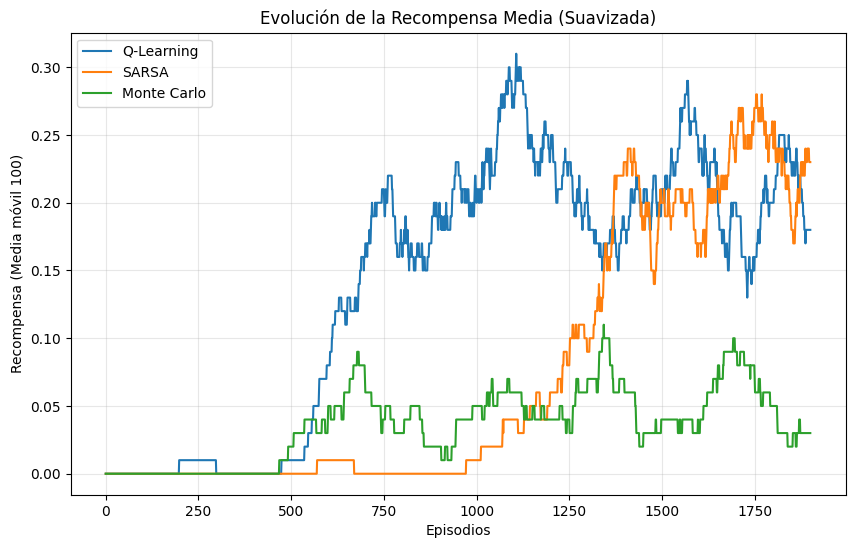

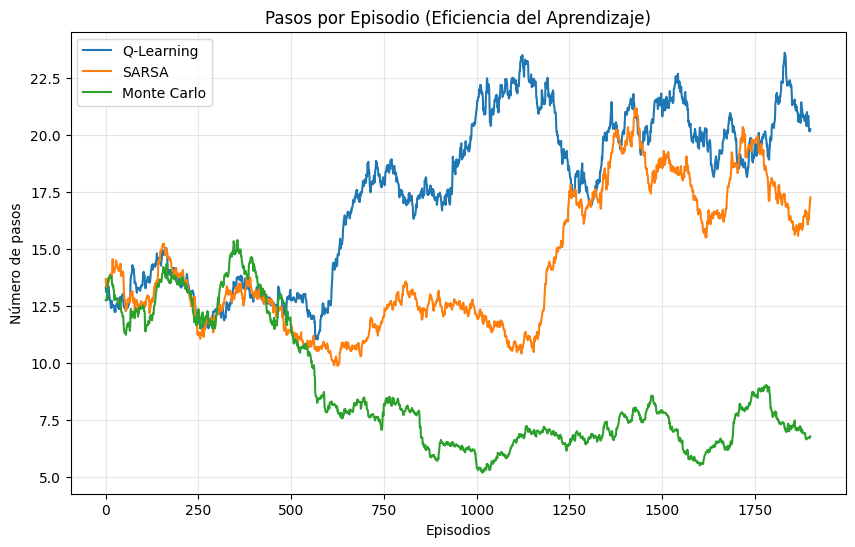

In [6]:
# Gráfica 1: Recompensa acumulada (Aprendizaje)
plot_learning_curves(results_reward, window=100)

# Gráfica 2: Pasos por episodio (Eficiencia)
plot_steps_per_episode(results_steps, window=100)

En la **recompensa media**, observamos que Q-Learning logra el mejor desempeño final al buscar la política óptima de forma off-policy. Por contra, SARSA demuestra un aprendizaje más estable y temprano, ya que su naturaleza on-policy le permite adaptarse a los riesgos de la exploración en el hielo resbaladizo. Notamos que Monte Carlo fracasa al mantenerse en $0.0$, lo cual atribuimos a la "recompensa dispersa": al no alcanzar la meta por azar, el agente no genera retornos para actualizar sus valores.

Respecto a la eficiencia (**pasos por episodio**), detectamos una alta varianza debido a que el entorno es estocástico (is_slippery=True). Sin embargo, apreciamos que SARSA tiende a encontrar rutas más cortas y seguras en los episodios finales. Este análisis nos permite concluir que, para entornos con recompensas retardadas e incertidumbre, la actualización paso a paso de los métodos de Diferencias Temporales es drásticamente más efectiva que la dependencia de episodios completos de Monte Carlo.

## 4.2. Evaluación en el entorno CliffWalking-v1

In [7]:
# Inicializar agentes para Cliff Walking
q_agent_cliff = QLearningAgent(env_cliff, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON)
sarsa_agent_cliff = SARSAAgent(env_cliff, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON)
mc_agent_cliff = MonteCarloAgent(env_cliff, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON)

# Diccionarios para resultados de Cliff Walking
results_reward_cliff = {}
results_steps_cliff = {}

# Entrenamiento
results_reward_cliff['Q-Learning'], results_steps_cliff['QL'] = train_tabular_agent(q_agent_cliff, 500, seed=seed)
results_reward_cliff['SARSA'], results_steps_cliff['SARSA'] = train_tabular_agent(sarsa_agent_cliff, 500, seed=seed)
results_reward_cliff['Monte Carlo'], results_steps_cliff['MC'] = train_tabular_agent(mc_agent_cliff, 500, seed=seed)

Entrenando MonteCarloAgent: 100%|██████████| 500/500 [00:45<00:00, 10.95it/s]


En cuanto a la **recompensa media**, observamos un contraste drástico entre los algoritmos. Q-Learning y SARSA demuestran una estabilidad superior, manteniéndose cerca de valores de recompensa esperados para este entorno al actualizar sus valores paso a paso. Por el contrario, detectamos un hundimiento masivo en el desempeño de Monte Carlo, con caídas que superan los $-400,000$. Atribuimos este comportamiento a la naturaleza de este algoritmo, que al sumar todas las penalizaciones acumuladas del episodio (pasos de $-1$ y caídas al acantilado de $-100$) antes de actualizar, genera retornos negativos extremos que saturan la tabla Q.

Respecto a la eficiencia (**pasos por episodio**), nuestros resultados confirman que Monte Carlo presenta una ineficiencia crítica en este escenario. Observamos picos que alcanzan los $120,000$ pasos por episodio en las fases iniciales, lo que indica que el agente queda atrapado en trayectorias cíclicas o cae repetidamente al acantilado sin aprender de esos errores en tiempo real. Mientras tanto, verificamos que SARSA y Q-Learning mantienen una longitud de episodio mínima y constante desde el principio, demostrando que la actualización inmediata mediante la ecuación de Bellman les permite optimizar la ruta hacia la meta de forma drásticamente más efectiva.

Mostramos los resultados gráficamente de la misma forma que con FrozenLake-v1.

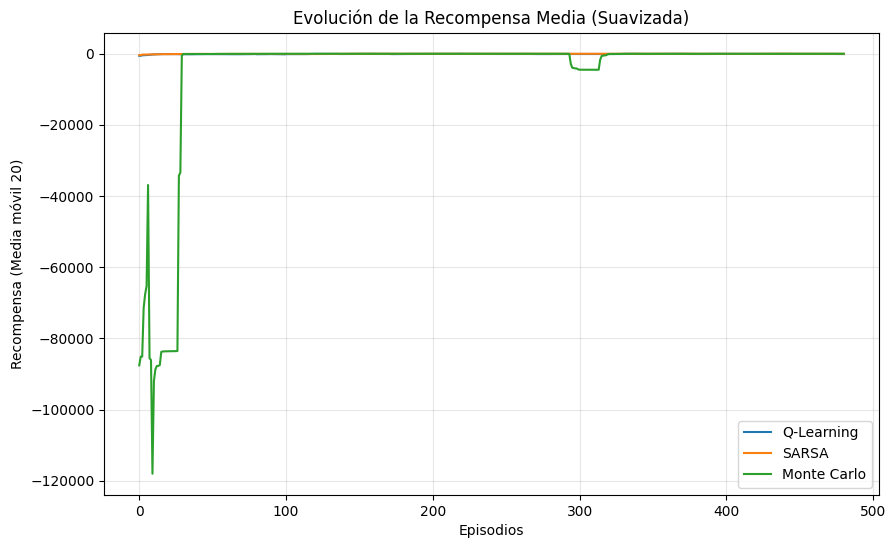

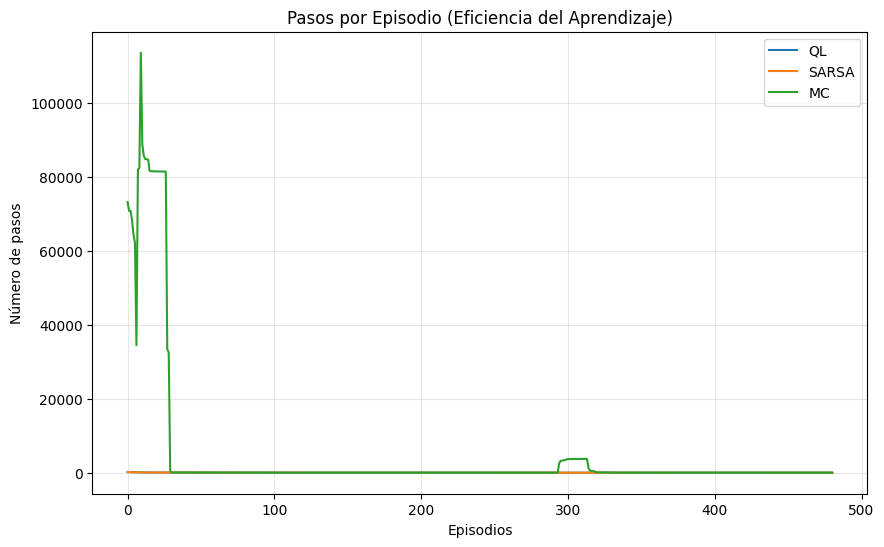

In [8]:
# Gráfica 1: Recompensa acumulada (Aprendizaje)
plot_learning_curves(results_reward_cliff, window=20)

# Gráfica 2: Pasos por episodio (Eficiencia)
plot_steps_per_episode(results_steps_cliff, window=20)

# 5. Conclusiones <a name="conclusiones"></a>

## 5.1. Conclusiones del entorno FrozenLake-v1

En este entorno estocástico, hemos verificado la superioridad de los métodos de Diferencias Temporales (TD) frente a Monte Carlo. Observamos que Q-Learning logra los mejores resultados de aprendizaje, aunque SARSA demuestra una mayor estabilidad inicial al adaptarse a la naturaleza resbaladiza del lago. Por otro lado, confirmamos que Monte Carlo fracasa debido a la recompensa dispersa, ya que, al no alcanzar la meta por azar, no genera retornos para actualizar la tabla Q. Concluimos que la actualización paso a paso es fundamental en entornos con alta incertidumbre en las transiciones.

## 5.2. Conclusiones del entorno CliffWalking-v1

Nuestra experimentación nos permite distinguir claramente entre políticas on-policy y off-policy. Hemos comprobado que SARSA adopta una política conservadora y segura para evitar el riesgo de caída derivado de la exploración $\epsilon$-greedy. Al contrario, Q-Learning busca la ruta óptima por el borde, asumiendo más caídas durante su fase de entrenamiento. Finalmente, destacamos la gran ineficiencia de Monte Carlo en este escenario, cuyos retornos negativos acumulados por las constantes caídas saturan los valores de estado-acción, impidiendo una convergencia práctica en comparación con los métodos TD.

# 6. Uso de la IA generativa <a name="ia-generativa"></a>

### Prompt 1. ¿Por qué Monte Carlo muestra valores de recompensa tan bajos en CliffWalking comparado con Q-Learning?
Esto ocurre porque Monte Carlo espera a terminar el episodio para actualizar la tabla Q. En entornos con penalizaciones por paso y caídas, el agente acumula una cantidad masiva de recompensas negativas antes de realizar su primera actualización. A diferencia de Q-Learning, que aprende paso a paso mediante diferencias temporales, Monte Carlo sufre de una varianza extrema que "envenena" sus estimaciones de valor si no alcanza la meta rápidamente.

### Prompt 2. En FrozenLake estocástico, ¿qué diferencia práctica hay entre la actualización de SARSA y Q-Learning?

La diferencia reside en cómo gestionan el riesgo del "hielo resbaladizo". SARSA es on-policy y actualiza el valor considerando la acción que realmente va a tomar (que puede ser un error de exploración), lo que le lleva a aprender rutas más seguras. Q-Learning es off-policy y actualiza asumiendo que siempre tomará la mejor acción posible en el siguiente estado, lo que le permite encontrar la ruta óptima pero le hace caer más veces durante el entrenamiento debido a su naturaleza arriesgada.

# 7. Bibliografía y referencias <a name="referencias"></a>

* Hernández Molinero, L. D. (2026). Aprendizaje por Refuerzo: Procesos de Decisión de Markov. Material de la asignatura Extensiones de Machine Learning. Máster en Inteligencia Artificial, Universidad de Murcia.

* Sutton, R. S., & Barto, A. G. (2018). Reinforcement Learning: An Introduction (2nd ed.). MIT Press. Referencia fundamental para la formulación de las ecuaciones de Bellman y la comparación entre métodos TD y Monte Carlo.

* Silver, D. (2015). Lectures on Reinforcement Learning. University College London. Recurso utilizado para profundizar en la teoría de funciones de valor y políticas óptimas.

* Gymnasium Documentation (2024). Training an Agent. Farama Foundation. Documentación técnica utilizada para la implementación de los entornos FrozenLake y CliffWalking.

* DeepMind x UCL. (2018). Reinforcement Learning Series. Impartido por Hado van Hasselt. Recurso audiovisual para el estudio de métodos aproximados y tabulares.